In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupKFold
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create results directory
os.makedirs('cnn_results', exist_ok=True)

class ADHD_CNN_Baseline(nn.Module):
    def __init__(self, num_channels=19):
        super(ADHD_CNN_Baseline, self).__init__()
        
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(num_channels, 32, kernel_size=15, padding=7),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4),
            
            nn.Conv1d(32, 64, kernel_size=15, padding=7),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4),
            
            nn.AdaptiveAvgPool1d(1) 
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3), 
            nn.Linear(32, 2)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1) 
        return self.classifier(x)

In [2]:
def run_subject_wise_training(X, y, groups):
    gkf = GroupKFold(n_splits=5)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nTraining on: {device}")

    fold_accuracies = []
    all_preds, all_labels = [], []
    failure_records = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups)):
        # 1. PER-SUBJECT NORMALIZATION (Crucial for raw signal variability)
        X_train_raw, y_train = X[train_idx], y[train_idx]
        X_test_raw, y_test = X[test_idx], y[test_idx]
        groups_test = groups[test_idx]

        # Standardizing: (X - mean) / std. Calculates mean/std across the time dimension (axis=2)
        X_train = (X_train_raw - np.mean(X_train_raw, axis=2, keepdims=True)) / (np.std(X_train_raw, axis=2, keepdims=True) + 1e-7)
        X_test = (X_test_raw - np.mean(X_test_raw, axis=2, keepdims=True)) / (np.std(X_test_raw, axis=2, keepdims=True) + 1e-7)

        # Convert to Tensors
        X_train_t, y_train_t = torch.FloatTensor(X_train), torch.LongTensor(y_train)
        X_test_t, y_test_t = torch.FloatTensor(X_test), torch.LongTensor(y_test)
        
        train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
        
        print(f"✅ Fold {fold+1}: Subject isolation verified. Unique test subjects: {len(np.unique(groups_test))}")
        
        model = ADHD_CNN_Baseline(num_channels=X.shape[1]).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()
        
        # Training loop
        for epoch in range(20):
            model.train()
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                optimizer.zero_grad() # RESET GRADIENTS - Mandatory fix
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
        
        # Evaluation & Failure Analysis
        model.eval()
        fold_preds, fold_true = [], []
        
        with torch.no_grad():
            outputs = model(X_test_t.to(device))
            preds = outputs.argmax(dim=1).cpu().numpy()
            
            for i in range(len(preds)):
                failure_records.append({
                    'Fold': fold + 1,
                    'Subject_ID': groups_test[i],
                    'Prediction': preds[i],
                    'True_Label': y_test[i],
                    'Correct': 1 if preds[i] == y_test[i] else 0
                })
                fold_preds.append(preds[i])
                fold_true.append(y_test[i])

        acc = 100 * np.mean(np.array(fold_preds) == np.array(fold_true))
        print(f"Fold {fold+1} Accuracy: {acc:.2f}%")
        fold_accuracies.append(acc)
        all_preds.extend(fold_preds)
        all_labels.extend(fold_true)

    print(f"\nFinal Cross-Subject Accuracy: {np.mean(fold_accuracies):.2f}%")
    
    # Save Failure Analysis
    df_fail = pd.DataFrame(failure_records)
    subject_analysis = df_fail.groupby(['Subject_ID', 'True_Label'])['Correct'].mean().reset_index()
    subject_analysis.columns = ['Subject_ID', 'Label', 'Accuracy_per_Subject']
    subject_analysis.to_csv('cnn_results/cnn_failed_subjects.csv', index=False)

    # Classification Report
    report = classification_report(all_labels, all_preds, target_names=['Control', 'ADHD'])
    with open('cnn_results/classification_report.txt', 'w') as f: f.write(report)

    # Confusion Matrix
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Control', 'ADHD'], yticklabels=['Control', 'ADHD'])
    plt.title('1D CNN Confusion Matrix')
    plt.show()

    return subject_analysis


Training on: cpu
✅ Fold 1: Subject isolation verified. Unique test subjects: 24
Fold 1 Accuracy: 78.61%
✅ Fold 2: Subject isolation verified. Unique test subjects: 24
Fold 2 Accuracy: 78.42%
✅ Fold 3: Subject isolation verified. Unique test subjects: 25
Fold 3 Accuracy: 77.35%
✅ Fold 4: Subject isolation verified. Unique test subjects: 24
Fold 4 Accuracy: 80.68%
✅ Fold 5: Subject isolation verified. Unique test subjects: 24
Fold 5 Accuracy: 73.80%

Final Cross-Subject Accuracy: 77.77%


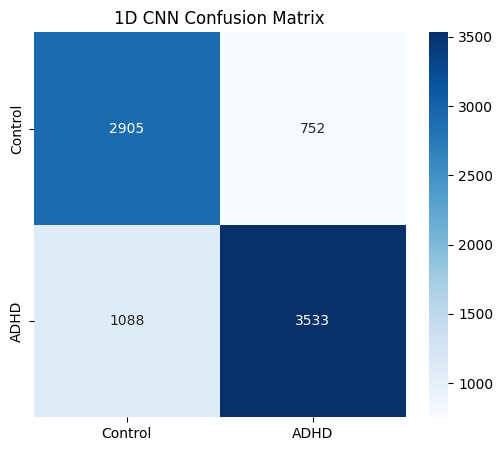

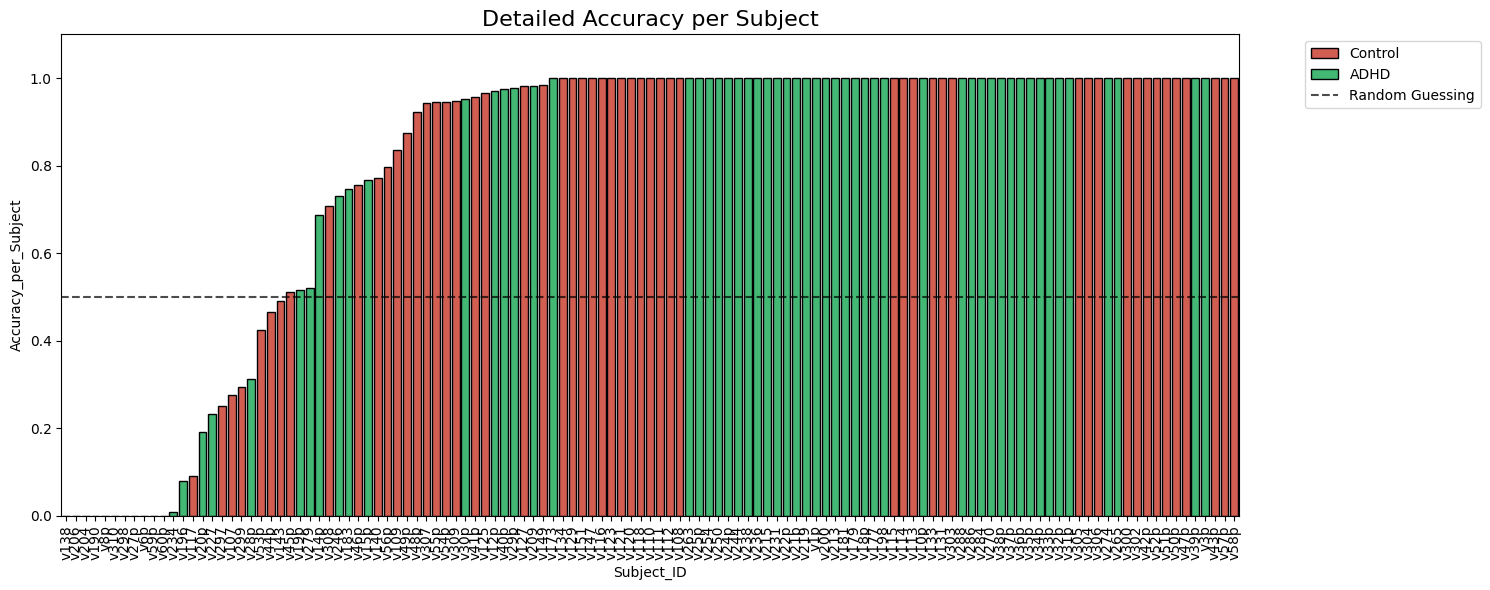

In [3]:
# Load pre-windowed data from your notebook output
data = np.load('/kaggle/input/datasets/thejeshwaar1610/sliced-eeg-for-adhd/adhd_windowed_data.npz')
X_dl = data['X']
y_dl = data['y']
groups_dl = data['groups']

# Run training
subject_stats = run_subject_wise_training(X_dl, y_dl, groups_dl)

# Visualization function
def visualize_legible_failures(subject_stats):
    subject_stats = subject_stats.sort_values(by='Accuracy_per_Subject')
    subject_stats['Class'] = subject_stats['Label'].map({0: 'Control', 1: 'ADHD'})
    
    plt.figure(figsize=(15, 6))
    colors = {"Control": "#e74c3c", "ADHD": "#2ecc71"}
    
    sns.barplot(data=subject_stats, x='Subject_ID', y='Accuracy_per_Subject', hue='Class', palette=colors, edgecolor='black')
    plt.axhline(0.5, color='black', linestyle='--', alpha=0.7, label='Random Guessing')
    plt.title("Detailed Accuracy per Subject", fontsize=16)
    plt.xticks(rotation=90)
    plt.ylim(0, 1.1)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

visualize_legible_failures(subject_stats)

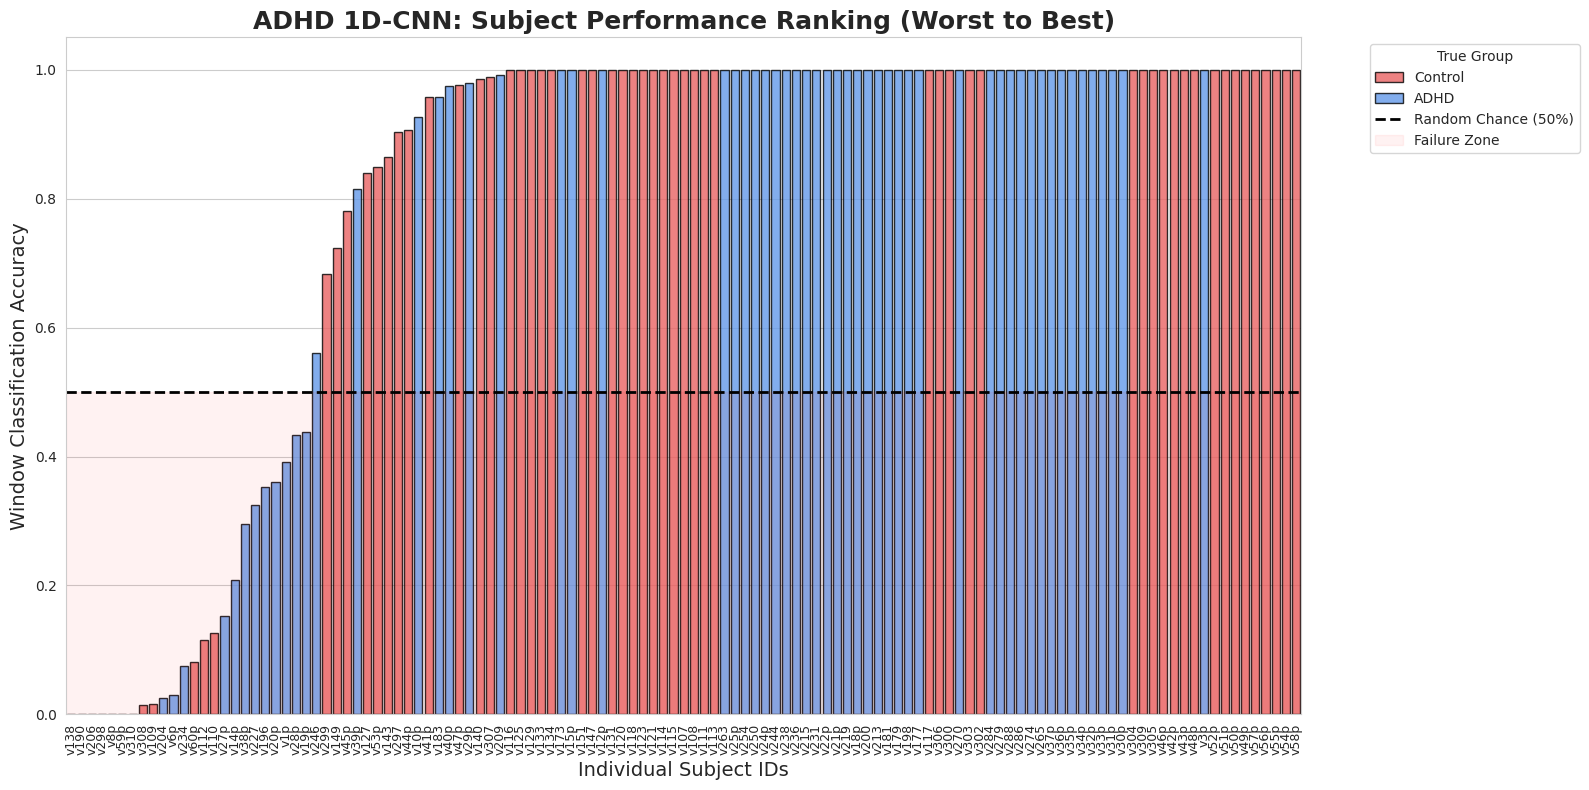

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the data
# Ensure the path matches where you saved your CSV
subject_stats = pd.read_csv('/kaggle/input/datasets/thejeshwaar1610/analysis-chart/cnn_failed_subjects.csv')

def plot_ranked_analysis(df):
    # Sort from worst accuracy to best
    df = df.sort_values('Accuracy_per_Subject').reset_index(drop=True)
    
    # Map 0/1 to readable labels
    df['Subject_Class'] = df['Label'].map({0: 'Control', 1: 'ADHD'})
    
    # Set the style
    plt.figure(figsize=(16, 8))
    sns.set_style("whitegrid")
    
    # Create the Barplot
    # We use a custom palette: Red for Controls that fail, Blue for ADHD
    colors = {"Control": "#ff4d4d", "ADHD": "#4d94ff"}
    
    ax = sns.barplot(
        data=df,
        x='Subject_ID',
        y='Accuracy_per_Subject',
        hue='Subject_Class',
        palette=colors,
        edgecolor='black',
        alpha=0.8
    )
    
    # Add the "Random Guessing" line at 0.5
    plt.axhline(0.5, color='black', linestyle='--', linewidth=2, label='Random Chance (50%)')
    
    # Add a "Failure Zone" highlight
    plt.axhspan(0, 0.5, color='red', alpha=0.05, label='Failure Zone')
    
    # Formatting
    plt.title('ADHD 1D-CNN: Subject Performance Ranking (Worst to Best)', fontsize=18, fontweight='bold')
    plt.xlabel('Individual Subject IDs', fontsize=14)
    plt.ylabel('Window Classification Accuracy', fontsize=14)
    plt.xticks(rotation=90, fontsize=9)
    plt.legend(title="True Group", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.ylim(0, 1.05)
    
    plt.tight_layout()
    plt.show()

# Run it
plot_ranked_analysis(subject_stats)